**Pothole Detection using DINOv2**
-----------------

In [1]:
import os
import numpy as np
import cv2
from glob import glob
from tqdm import tqdm
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from torchvision import transforms
import torchvision.transforms.functional as TF

In [2]:
import os
import random
import shutil

def split_pothrgbd_dataset(
    input_root,
    output_root="/kaggle/working/pothrgbd_split",
    train_ratio=0.7,
    val_ratio=0.2,
    test_ratio=0.1,
    seed=42
):
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6

    image_dir = os.path.join(input_root, "images")
    depth_dir = os.path.join(input_root, "depths")
    label_dir = os.path.join(input_root, "labels")

    image_files = sorted([
        f for f in os.listdir(image_dir)
        if os.path.isfile(os.path.join(image_dir, f)) and f.lower().endswith(".jpg")
    ])

    samples = []
    for img_name in image_files:
        stem = os.path.splitext(img_name)[0]
        img_path = os.path.join(image_dir, img_name)
        label_path = os.path.join(label_dir, stem + ".txt")

        # depth is optional for now
        # map by timestamp prefix before "_color"
        depth_path = None
        base_prefix = stem.split("_color")[0]

        for f in os.listdir(depth_dir):
            if f.startswith(base_prefix) and f.endswith(".npy"):
                depth_path = os.path.join(depth_dir, f)
                break

        if os.path.exists(label_path):
            samples.append((img_path, depth_path, label_path, stem))

    print("Found image files:", len(image_files))
    print("Found valid matched samples:", len(samples))

    random.seed(seed)
    random.shuffle(samples)

    n = len(samples)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)

    train_samples = samples[:n_train]
    val_samples = samples[n_train:n_train + n_val]
    test_samples = samples[n_train + n_val:]

    for split_name, split_samples in {
        "train": train_samples,
        "valid": val_samples,
        "test": test_samples
    }.items():
        for sub in ["images", "depths", "labels"]:
            os.makedirs(os.path.join(output_root, split_name, sub), exist_ok=True)

        for img_path, depth_path, label_path, stem in split_samples:
            shutil.copy2(img_path, os.path.join(output_root, split_name, "images", os.path.basename(img_path)))
            shutil.copy2(label_path, os.path.join(output_root, split_name, "labels", os.path.basename(label_path)))
            if depth_path is not None:
                shutil.copy2(depth_path, os.path.join(output_root, split_name, "depths", os.path.basename(depth_path)))

    print("Done")
    print("Saved to:", output_root)
    print("Train:", len(train_samples))
    print("Valid:", len(val_samples))
    print("Test :", len(test_samples))

In [3]:
split_pothrgbd_dataset(
    input_root="/kaggle/input/datasets/mahyeks/pothrgbd-rgb-and-depth-images-of-potholes/PUBLIC POTHOLE DATASET",
    output_root="/kaggle/working/pothrgbd_split",
    train_ratio=0.7,
    val_ratio=0.2,
    test_ratio=0.1,
    seed=42
)

Found image files: 1000
Found valid matched samples: 1000
Done
Saved to: /kaggle/working/pothrgbd_split
Train: 700
Valid: 200
Test : 100


In [4]:
import os

print(os.listdir("/kaggle/working/pothrgbd_split"))
print(os.listdir("/kaggle/working/pothrgbd_split/train"))
print(len(os.listdir("/kaggle/working/pothrgbd_split/train/images")))
print(len(os.listdir("/kaggle/working/pothrgbd_split/train/labels")))
print(len(os.listdir("/kaggle/working/pothrgbd_split/train/depths")))

['valid', 'train', 'test']
['labels', 'images', 'depths']
700
700
698


In [5]:
import os
from glob import glob

root = "/kaggle/input/datasets/mahyeks/pothrgbd-rgb-and-depth-images-of-potholes/PUBLIC POTHOLE DATASET"

print("ROOT EXISTS:", os.path.exists(root))
print("ROOT CONTENTS:", os.listdir(root))

image_dir = os.path.join(root, "images")
depth_dir = os.path.join(root, "depths")
label_dir = os.path.join(root, "labels")

print("image_dir exists:", os.path.exists(image_dir))
print("depth_dir exists:", os.path.exists(depth_dir))
print("label_dir exists:", os.path.exists(label_dir))

print("sample images:", os.listdir(image_dir)[:10])
print("sample depths:", os.listdir(depth_dir)[:10])
print("sample labels:", os.listdir(label_dir)[:10])

print("png images:", len(glob(os.path.join(image_dir, "*.png"))))
print("jpg images:", len(glob(os.path.join(image_dir, "*.jpg"))))
print("jpeg images:", len(glob(os.path.join(image_dir, "*.jpeg"))))
print("PNG images:", len(glob(os.path.join(image_dir, "*.PNG"))))
print("JPG images:", len(glob(os.path.join(image_dir, "*.JPG"))))
print("JPEG images:", len(glob(os.path.join(image_dir, "*.JPEG"))))

ROOT EXISTS: True
ROOT CONTENTS: ['labels', 'images', 'depths']
image_dir exists: True
depth_dir exists: True
label_dir exists: True
sample images: ['20250305_125116_color_png.rf.c18f20c2159fedc413299006aeb78f79.jpg', '20250305_102338_color_png.rf.4fe894853f2689cbfde68ac67c13272a.jpg', '20250305_045716_color_png.rf.df5ffb5e034f129034d357ffecaabf87.jpg', '20250305_052425_color_png.rf.bd7f21fc6aa28776be1c06423ee15e6b.jpg', '20250305_124838_color_png.rf.1996e1f50b282731e98182c7976820af.jpg', '20250227_171010_color_png.rf.ab09c4a9990ad0ee13ee03eab371512b.jpg', '20250305_060025_color_png.rf.600b9306348488df84aca5d149a65a6b.jpg', '20250227_174207_color_png.rf.1ace7fd4923d3a1aa1272574b75706be.jpg', '20250305_131835_color_png.rf.f7d6293f59dfe6f22cd814737441d5e0.jpg', '20250305_041507_color_png.rf.9159d8b59413f98b10d167a3689ab3cb.jpg']
sample depths: ['20250227_170624_depth.npy', '20250305_095805_depth.npy', '20250227_185135_depth.npy', '20250305_142058_depth.npy', '20250305_124338_depth.npy', 

In [6]:
import os
print(os.listdir("/kaggle/working/pothrgbd_split"))
print(os.listdir("/kaggle/working/pothrgbd_split/train"))
print(len(os.listdir("/kaggle/working/pothrgbd_split/train/images")))

['valid', 'train', 'test']
['labels', 'images', 'depths']
700


--------------
**Data Augmentation**

In [7]:
class JointAugment:
    """
    Applies augmentations jointly to (image, mask) so they stay aligned.
 
    Spatial transforms  → applied to BOTH image and mask.
    Appearance transforms → applied to image ONLY (mask geometry is unchanged).
 
    The four required augmentation types are each handled in their own
    clearly labelled block below:
 
        1. Light intensity   – brightness / contrast / saturation / hue
        2. Blur              – Gaussian blur (varying kernel size)
        3. Light + Blur      – dedicated combined pass so the pairing is
                               always explicitly represented in training
        4. Rotation          – random rotation up to ±30°
 
    Parameters
    ----------
    is_train : bool
        When False (validation / test), the instance is a no-op.
    flip_p   : float   Probability of each flip.
    rotate_p : float   Probability of applying rotation.
    crop_p   : float   Probability of random crop-and-resize.
    light_p  : float   Probability of the light-intensity block firing.
    blur_p   : float   Probability of the blur-only block firing.
    combo_p  : float   Probability of the combined light+blur block firing.
    """
 
    def __init__(
        self,
        is_train: bool = True,
        flip_p:   float = 0.5,
        rotate_p: float = 0.5,
        crop_p:   float = 0.5,
        light_p:  float = 0.6,
        blur_p:   float = 0.4,
        combo_p:  float = 0.3,
    ):
        self.is_train = is_train
        self.flip_p   = flip_p
        self.rotate_p = rotate_p
        self.crop_p   = crop_p
        self.light_p  = light_p
        self.blur_p   = blur_p
        self.combo_p  = combo_p
 
    # ------------------------------------------------------------------
    # Internal helpers
    # ------------------------------------------------------------------
 
    def _apply_light(self, img: torch.Tensor) -> torch.Tensor:
        """
        Augmentation 1 — Light intensity
        Randomly perturbs brightness, contrast, saturation, and hue to
        simulate different times of day, overcast skies, and headlight
        / streetlight conditions.
        """
        # Brightness: simulate under-/over-exposed road images
        if random.random() > 0.3:
            factor = random.uniform(0.4, 1.8)   # wider range than standard
            img = TF.adjust_brightness(img, factor)
 
        # Contrast: simulate flat (foggy) vs high-contrast (midday) lighting
        if random.random() > 0.3:
            img = TF.adjust_contrast(img, random.uniform(0.5, 1.8))
 
        # Saturation: desaturate → wet/overcast; boost → dry sunny road
        if random.random() > 0.4:
            img = TF.adjust_saturation(img, random.uniform(0.3, 1.7))
 
        # Hue: minor shift to simulate different camera white-balance settings
        if random.random() > 0.5:
            img = TF.adjust_hue(img, random.uniform(-0.12, 0.12))
 
        return img
 
    def _apply_blur(self, img: torch.Tensor) -> torch.Tensor:
        """
        Augmentation 2 — Blur
        Simulates motion blur (moving vehicle), rain / water on lens,
        and shallow depth-of-field from dashcam optics.
        Kernel size is sampled from a set of odd integers so it is always
        valid for torchvision's gaussian_blur.
        """
        kernel_size = random.choice([3, 5, 7, 9])
        sigma       = random.uniform(0.5, 3.0)   # wider sigma → heavier blur
        img = TF.gaussian_blur(img, kernel_size=kernel_size, sigma=sigma)
        return img
 
    # ------------------------------------------------------------------
    # Public interface
    # ------------------------------------------------------------------
 
    def __call__(
        self,
        img:  torch.Tensor,
        mask: torch.Tensor,
    ):
        """
        Parameters
        ----------
        img  : float32 tensor (3, H, W) in [0, 1]
        mask : float32 tensor (1, H, W) in {0, 1}
 
        Returns
        -------
        Augmented (img, mask) tensors of the same shape.
        """
        if not self.is_train:
            return img, mask
 
        # ----------------------------------------------------------------
        # SPATIAL TRANSFORMS  (applied to both image and mask)
        # ----------------------------------------------------------------
 
        # Horizontal flip
        if random.random() < self.flip_p:
            img  = TF.hflip(img)
            mask = TF.hflip(mask)
 
        # Vertical flip (less common in real dashcam data, lower probability)
        if random.random() < self.flip_p * 0.5:
            img  = TF.vflip(img)
            mask = TF.vflip(mask)
 
        # ------ Augmentation 4: Rotation ------
        # Simulates camera tilt, road camber, drone angle variation
        if random.random() < self.rotate_p:
            angle = random.uniform(-30, 30)   # ±30° covers most real-world tilt
            img  = TF.rotate(img,  angle,
                             interpolation=TF.InterpolationMode.BILINEAR,
                             fill=0)
            mask = TF.rotate(mask, angle,
                             interpolation=TF.InterpolationMode.NEAREST,
                             fill=0)
 
        # Random crop-and-resize (zoom simulation / scale augmentation)
        if random.random() < self.crop_p:
            _, H, W = img.shape
            scale   = random.uniform(0.70, 1.0)
            crop_h  = int(H * scale)
            crop_w  = int(W * scale)
            top     = random.randint(0, H - crop_h)
            left    = random.randint(0, W - crop_w)
            img  = TF.resized_crop(img,  top, left, crop_h, crop_w, (H, W),
                                   interpolation=TF.InterpolationMode.BILINEAR)
            mask = TF.resized_crop(mask, top, left, crop_h, crop_w, (H, W),
                                   interpolation=TF.InterpolationMode.NEAREST)
 
        # ----------------------------------------------------------------
        # APPEARANCE TRANSFORMS  (image only — three distinct scenarios)
        # ----------------------------------------------------------------
 
        # ------ Augmentation 1: Light intensity only ------
        if random.random() < self.light_p:
            img = self._apply_light(img)
 
        # ------ Augmentation 2: Blur only ------
        if random.random() < self.blur_p:
            img = self._apply_blur(img)
 
        # ------ Augmentation 3: Light + Blur combined ------
        # This block is independent of the two above, so all three
        # scenarios (light-only, blur-only, light+blur) can occur in
        # any combination within a single sample.
        if random.random() < self.combo_p:
            img = self._apply_light(img)
            img = self._apply_blur(img)
 
        # ----------------------------------------------------------------
        # Clamp to valid range after all appearance transforms
        # ----------------------------------------------------------------
        img = img.clamp(0.0, 1.0)
 
        return img, mask

In [8]:
split_pothrgbd_dataset(
    input_root="/kaggle/input/datasets/mahyeks/pothrgbd-rgb-and-depth-images-of-potholes/PUBLIC POTHOLE DATASET",
    output_root="/kaggle/working/pothrgbd_split",
    train_ratio=0.7,
    val_ratio=0.2,
    test_ratio=0.1,
    seed=42
)

Found image files: 1000
Found valid matched samples: 1000
Done
Saved to: /kaggle/working/pothrgbd_split
Train: 700
Valid: 200
Test : 100


------------------
**Dataset Loader**

In [9]:

class PothRGBDDataset(Dataset):
    def __init__(self, split_dir: str, img_size: int = 448, augment: bool = False):
        self.split_dir = split_dir
        self.img_size = img_size
        self.augmentor = JointAugment(is_train=augment)

        self.image_paths = sorted(
            glob(os.path.join(split_dir, "images", "*.jpg")) +
            glob(os.path.join(split_dir, "images", "*.jpeg")) +
            glob(os.path.join(split_dir, "images", "*.png"))
        )

        if len(self.image_paths) == 0:
            raise FileNotFoundError(f"No images found in {os.path.join(split_dir, 'images')}")

        self.samples = []
        for img_path in self.image_paths:
            stem = os.path.splitext(os.path.basename(img_path))[0]
            label_path = os.path.join(split_dir, "labels", stem + ".txt")

            depth_path = None
            base_prefix = stem.split("_color")[0]
            
            for f in os.listdir(os.path.join(split_dir, "depths")):
                if f.startswith(base_prefix) and f.endswith(".npy"):
                    depth_path = os.path.join(split_dir, "depths", f)
                    break

            if os.path.exists(label_path):
                self.samples.append((img_path, depth_path, label_path, stem))

        print(f"[{os.path.basename(split_dir)}] samples: {len(self.samples)} | augment: {augment}")

    def __len__(self):
        return len(self.samples)

    def _polygon_to_mask(self, label_path, h, w):
        mask = np.zeros((h, w), dtype=np.uint8)

        if not os.path.exists(label_path):
            return mask

        with open(label_path, "r") as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()
            if len(parts) < 7:
                continue

            cls_id = int(float(parts[0]))
            coords = list(map(float, parts[1:]))

            if len(coords) % 2 != 0:
                continue

            points = []
            for i in range(0, len(coords), 2):
                x = int(coords[i] * w)
                y = int(coords[i + 1] * h)
                x = max(0, min(w - 1, x))
                y = max(0, min(h - 1, y))
                points.append([x, y])

            if len(points) >= 3:
                pts = np.array(points, dtype=np.int32)
                cv2.fillPoly(mask, [pts], 1)

        return mask

    def __getitem__(self, idx):
        image_path, depth_path, label_path, stem = self.samples[idx]

        img = cv2.imread(image_path, cv2.IMREAD_COLOR)
        if img is None:
            raise FileNotFoundError(f"Could not read image: {image_path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        mask = self._polygon_to_mask(label_path, h, w)

        if depth_path is not None and os.path.exists(depth_path):
            depth = np.load(depth_path).astype(np.float32)
        
            if depth.ndim == 3:
                depth = depth[..., 0]
        
            if depth.shape != (h, w):
                depth = cv2.resize(depth, (w, h), interpolation=cv2.INTER_LINEAR)
        
            if depth.max() > depth.min():
                depth = (depth - depth.min()) / (depth.max() - depth.min() + 1e-8)
            else:
                depth = np.zeros((h, w), dtype=np.float32)
        else:
            depth = np.zeros((h, w), dtype=np.float32)

        img = cv2.resize(img, (self.img_size, self.img_size), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)
        depth = cv2.resize(depth, (self.img_size, self.img_size), interpolation=cv2.INTER_LINEAR)

        img = torch.tensor(img).permute(2, 0, 1).float() / 255.0
        mask = torch.tensor(mask).unsqueeze(0).float()
        depth = torch.tensor(depth).unsqueeze(0).float()

        img, mask = self.augmentor(img, mask)

        return img, depth, mask


def build_dataloaders(base_path: str, img_size: int = 448, batch_size: int = 8, num_workers: int = 2):
    train_dataset = PothRGBDDataset(os.path.join(base_path, "train"), img_size=img_size, augment=True)
    val_dataset = PothRGBDDataset(os.path.join(base_path, "valid"), img_size=img_size, augment=False)
    test_dataset = PothRGBDDataset(os.path.join(base_path, "test"), img_size=img_size, augment=False)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

    return train_loader, val_loader, test_loader
 
 
# ============================================================
# QUICK SANITY CHECK  (run this cell on Kaggle to verify)
# ============================================================
 
if __name__ == "__main__":
    BASE_PATH = "/kaggle/input/datasets/mahyeks/pothrgbd-rgb-and-depth-images-of-potholes/PUBLIC POTHOLE DATASET"
 
    train_loader, val_loader, test_loader = build_dataloaders(
        base_path="/kaggle/working/pothrgbd_split",
        img_size=448,
        batch_size=8,
        num_workers=2,
    )
 
    # --- Single-sample check ---
    img, depth, mask = train_loader.dataset[0]
    print("\n-- Single sample --")
    print("Image shape :", img.shape)     # (3, 392, 392)
    print("Depth shape :", depth.shape)   # (1, 392, 392)  — zeros
    print("Mask  shape :", mask.shape)    # (1, 392, 392)
    print("Image min/max:", img.min().item(), img.max().item())
    print("Mask unique  :", torch.unique(mask).tolist())
 
    # --- Batch check ---
    imgs, depths, masks = next(iter(train_loader))
    print("\n-- Batch --")
    print("imgs  :", imgs.shape)    # (4, 3, 392, 392)
    print("depths:", depths.shape)  # (4, 1, 392, 392)
    print("masks :", masks.shape)   # (4, 1, 392, 392)
 
    # --- Find first sample with a pothole mask ---
    print("\n-- Pothole search (first 200 samples) --")
    for i in range(min(200, len(train_loader.dataset))):
        _, _, m = train_loader.dataset[i]
        if m.sum() > 0:
            print(f"Found pothole at index: {i}")
            break
    else:
        print("No pothole mask found in first 200 samples — check label paths.")

[train] samples: 700 | augment: True
[valid] samples: 200 | augment: False
[test] samples: 100 | augment: False

-- Single sample --
Image shape : torch.Size([3, 448, 448])
Depth shape : torch.Size([1, 448, 448])
Mask  shape : torch.Size([1, 448, 448])
Image min/max: 0.0 0.8320333957672119
Mask unique  : [0.0, 1.0]

-- Batch --
imgs  : torch.Size([8, 3, 448, 448])
depths: torch.Size([8, 1, 448, 448])
masks : torch.Size([8, 1, 448, 448])

-- Pothole search (first 200 samples) --
Found pothole at index: 0


------------------
**DINOv2 with RGB (Segmentation Model) with ViT-B (Base**

I used ViT-B because even though its slower than ViT-S (ViT-S is faster and uses less VRAM), its way more accurate by X%

In [10]:

class ASPP(nn.Module):
    """
    Lightweight Atrous Spatial Pyramid Pooling.
    Aggregates context at multiple scales using parallel dilated convolutions,
    then fuses them. This helps detect both small and large potholes.
 
    Input / output channels are both `in_channels` → `out_channels`.
    """
 
    def __init__(self, in_channels: int = 768, out_channels: int = 256):
        super().__init__()
 
        # 1×1 conv — pointwise context
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
 
        # 3×3 dilated convolutions — rates chosen to cover small / mid / large potholes
        self.conv2 = self._dilated(in_channels, out_channels, rate=6)
        self.conv3 = self._dilated(in_channels, out_channels, rate=12)
        self.conv4 = self._dilated(in_channels, out_channels, rate=18)
 
        # Global average pooling branch — captures whole-image context
        # NOTE: BatchNorm2d is NOT used here because GAP produces a (B, C, 1, 1)
        # tensor. BN requires >1 spatial value per channel and will crash with
        # "Expected more than 1 value per channel" when it sees a 1×1 map.
        # GroupNorm operates over channels only and works at any spatial size.
        self.gap = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.GroupNorm(num_groups=32, num_channels=out_channels),
            nn.ReLU(inplace=True),
        )
 
        # Projection — fuse 5 branches back to out_channels
        self.project = nn.Sequential(
            nn.Conv2d(out_channels * 5, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=0.1),
        )
 
    @staticmethod
    def _dilated(in_ch, out_ch, rate):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3,
                      padding=rate, dilation=rate, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
 
    def forward(self, x):
        _, _, H, W = x.shape
        gap_out    = F.interpolate(self.gap(x), size=(H, W),
                                   mode='bilinear', align_corners=False)
        fused = torch.cat([
            self.conv1(x),
            self.conv2(x),
            self.conv3(x),
            self.conv4(x),
            gap_out,
        ], dim=1)
        return self.project(fused)
 
 
class DecoderBlock(nn.Module):
    """
    Single decoder stage: Conv-BN-ReLU → upsample.
    Using bilinear upsample + conv (instead of transposed conv)
    avoids checkerboard artifacts common in segmentation decoders.
    """
 
    def __init__(self, in_ch: int, out_ch: int, output_size=None, scale_factor=None):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
        self.output_size  = output_size
        self.scale_factor = scale_factor
 
    def forward(self, x):
        x = self.conv(x)
        if self.output_size is not None:
            x = F.interpolate(x, size=self.output_size,
                              mode='bilinear', align_corners=False)
        elif self.scale_factor is not None:
            x = F.interpolate(x, scale_factor=self.scale_factor,
                              mode='bilinear', align_corners=False)
        return x
 
 
class DinoSegmentationModel(nn.Module):
    """
    Pothole segmentation model built on a frozen DINOv2 ViT-B backbone
    with an ASPP neck and a progressive upsampling decoder.
 
    Parameters
    ----------
    backbone : nn.Module
        A DINOv2 ViT-B model loaded via torch.hub.
        embed_dim must be 768 (ViT-B default).
    """
 
    # ViT-B specifics
    EMBED_DIM  = 768
    PATCH_SIZE = 14
 
    def __init__(self, backbone: nn.Module):
        super().__init__()
        self.backbone = backbone
 
        # Freeze all backbone parameters (Stage 1)
        for param in self.backbone.parameters():
            param.requires_grad = False
 
        # ---- Neck: ASPP multi-scale context ----
        self.aspp = ASPP(in_channels=self.EMBED_DIM, out_channels=256)
 
        # ---- Decoder: 32 → 64 → 128 → 256 → 448 ----
        # img_size = (448//14)*14 = 448, patch grid = 448/14 = 32×32
        self.dec1 = DecoderBlock(256, 256, scale_factor=2)   # 32  → 64
        self.dec2 = DecoderBlock(256, 128, scale_factor=2)   # 64  → 128
        self.dec3 = DecoderBlock(128,  64, scale_factor=2)   # 128 → 256
        self.dec4 = DecoderBlock( 64,  32, output_size=(448, 448))  # 256 → 448
 
        # ---- Segmentation head ----
        self.seg_head = nn.Conv2d(32, 1, kernel_size=1)
 
        # ---- Weight initialisation ----
        self._init_weights()
 
    def _init_weights(self):
        """Xavier uniform init on all decoder + head layers."""
        for m in [self.aspp, self.dec1, self.dec2, self.dec3, self.dec4, self.seg_head]:
            for layer in m.modules():
                if isinstance(layer, nn.Conv2d):
                    nn.init.xavier_uniform_(layer.weight)
                    if layer.bias is not None:
                        nn.init.zeros_(layer.bias)
                elif isinstance(layer, nn.BatchNorm2d):
                    nn.init.ones_(layer.weight)
                    nn.init.zeros_(layer.bias)
 
    def unfreeze_top_layers(self, n: int = 4):
        """
        Stage 2: unfreeze the top-n transformer blocks of the backbone
        for domain-specific fine-tuning.
 
        DINOv2 ViT-B has 12 transformer blocks (indices 0–11).
        Recommended: start with n=3, increase if val Dice plateaus.
 
        Example
        -------
        >>> model.unfreeze_top_layers(n=4)
        """
        # First re-freeze everything
        for param in self.backbone.parameters():
            param.requires_grad = False
 
        blocks = list(self.backbone.blocks)   # list of transformer blocks
        for block in blocks[-n:]:
            for param in block.parameters():
                param.requires_grad = True
 
        # Always unfreeze the final norm layer
        if hasattr(self.backbone, 'norm'):
            for param in self.backbone.norm.parameters():
                param.requires_grad = True
 
        unfrozen = sum(p.requires_grad for p in self.backbone.parameters())
        print(f"Unfrozen top {n} backbone blocks  "
              f"({unfrozen:,} backbone params now trainable)")
 
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Parameters
        ----------
        x : (B, 3, 448, 448)  float32, values in [0, 1]
 
        Returns
        -------
        logits : (B, 1, 448, 448)  — pass through sigmoid for probabilities
        """
        # ---- Backbone feature extraction ----
        features     = self.backbone.forward_features(x)
        patch_tokens = features["x_norm_patchtokens"]   # (B, 1024, 768)  32×32 grid
 
        B, N, C = patch_tokens.shape
        H = W   = int(N ** 0.5)                         # 32
        feat_map = patch_tokens.permute(0, 2, 1).reshape(B, C, H, W)  # (B, 768, 32, 32)
 
        # ---- Neck ----
        neck = self.aspp(feat_map)    # (B, 256, 32, 32)
 
        # ---- Decoder ----
        d1 = self.dec1(neck)          # (B, 256, 64,  64)
        d2 = self.dec2(d1)            # (B, 128, 128, 128)
        d3 = self.dec3(d2)            # (B,  64, 256, 256)
        d4 = self.dec4(d3)            # (B,  32, 448, 448)
 
        # ---- Head ----
        return self.seg_head(d4)      # (B,   1, 448, 448)
 
 
# ============================================================
# QUICK SANITY CHECK
# ============================================================
 
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)
 
    # Load ViT-B backbone
    backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')
    backbone = backbone.to(device).eval()
    print("DINOv2 ViT-B loaded.")
 
    model = DinoSegmentationModel(backbone).to(device)
    print("Model built.")
 
    # Count parameters
    total   = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total params    : {total:,}")
    print(f"Trainable params: {trainable:,}  (backbone frozen)")
 
    # Forward pass
    dummy = torch.randn(2, 3, 448, 448).to(device)
    with torch.no_grad():
        out = model(dummy)
    print(f"Output shape: {out.shape}")   # (2, 1, 448, 448)
    assert out.shape == (2, 1, 448, 448), "Shape mismatch!"
    print("Forward pass OK.")
 
    # Test Stage 2 unfreeze
    model.unfreeze_top_layers(n=4)
    trainable_s2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable params after unfreeze: {trainable_s2:,}")

Device: cuda
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth


100%|██████████| 330M/330M [00:01<00:00, 302MB/s]


DINOv2 ViT-B loaded.
Model built.
Total params    : 94,375,073
Trainable params: 7,794,593  (backbone frozen)
Output shape: torch.Size([2, 1, 448, 448])
Forward pass OK.
Unfrozen top 4 backbone blocks  (58 backbone params now trainable)
Trainable params after unfreeze: 36,153,761


------------------
**Training Stage: Frozen and Partial Unfreeze**

In [11]:
# ============================================================
# CONFIG
# ============================================================
 
CFG = {
    # Data — img_size matches teammate: (448//14)*14 = 448
    "base_path"   : "/kaggle/working/pothrgbd_split",
    "img_size"    : (448 // 14) * 14,   # = 448, ensures exact patch alignment
    "batch_size"  : 8,
    "num_workers" : 2,
 
    # Stage 1 — frozen backbone, decoder + ASPP only
    # ~40% of total epochs (warmup 3 + stage1 up to ~25)
    "stage1_epochs" : 25, #CHANGE THIS BACK TO 25 LATER OWEN REMEMBER
    "stage1_lr"     : 1e-4,
 
    # Stage 2 — top-4 backbone blocks unfrozen, remaining 35 epochs
    "stage2_epochs"      : 35,#CHANGE THIS BACK TO 35 LATER OWENNN
    "stage2_lr_head"     : 1e-4,   
    "stage2_lr_backbone" : 1e-5,    # 10× lower to avoid catastrophic forgetting
 
    # Shared — matches teammate wd exactly
    "weight_decay"    : 1e-4,
    "eta_min"         : 1e-6,
    "warmup_epochs"   : 3,          
    "unfreeze_n_blocks": 4,
 
    # Checkpointing
    "save_dir"  : "/kaggle/working",
    "save_name" : "best_model.pth",
}
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
 
 
# ============================================================
# METRICS
# ============================================================
 
def dice_score(pred: torch.Tensor, target: torch.Tensor, threshold: float = 0.5) -> float:
    pred         = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred * target).sum()
    union        = pred.sum() + target.sum()
    return ((2. * intersection + 1e-8) / (union + 1e-8)).item()
 
 
def iou_score(pred: torch.Tensor, target: torch.Tensor, threshold: float = 0.5) -> float:
    pred         = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred * target).sum()
    union        = pred.sum() + target.sum() - intersection
    return ((intersection + 1e-8) / (union + 1e-8)).item()
 
 
# ============================================================
# LOSS
# Combined BCE + Dice loss.
# BCE alone struggles with class imbalance (road >> pothole pixels).
# Adding Dice loss directly optimises the overlap metric we care about.
# ============================================================
 
class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight: float = 0.5):
        super().__init__()
        self.bce_weight  = bce_weight
        self.bce         = nn.BCEWithLogitsLoss()
 
    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        bce_loss  = self.bce(logits, targets)
 
        probs     = torch.sigmoid(logits)
        inter     = (probs * targets).sum(dim=(1, 2, 3))
        union     = probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
        dice_loss = 1.0 - ((2. * inter + 1e-8) / (union + 1e-8)).mean()
 
        return self.bce_weight * bce_loss + (1 - self.bce_weight) * dice_loss
 
 
# ============================================================
# ONE EPOCH
# ============================================================
 
def run_epoch(model, loader, criterion, optimizer, is_train: bool):
    model.train() if is_train else model.eval()
 
    total_loss = total_dice = total_iou = 0.0
    ctx        = torch.enable_grad() if is_train else torch.no_grad()
 
    with ctx:
        for imgs, depths, masks in tqdm(loader, leave=False):
            imgs  = imgs.to(device)
            masks = masks.to(device)
 
            if is_train:
                optimizer.zero_grad()
 
            logits = model(imgs)
            loss   = criterion(logits, masks)
 
            if is_train:
                loss.backward()
                # Gradient clipping — prevents large updates destabilising
                # the partially unfrozen backbone in Stage 2
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
 
            total_loss += loss.item()
            total_dice += dice_score(logits, masks)
            total_iou  += iou_score(logits,  masks)
 
    n = len(loader)
    return total_loss / n, total_dice / n, total_iou / n
 
 
# ============================================================
# STAGE RUNNER
# ============================================================
 
def run_stage(
    stage_num   : int,
    model       : nn.Module,
    train_loader,
    val_loader,
    epochs      : int,
    optimizer   : torch.optim.Optimizer,
    scheduler   : torch.optim.lr_scheduler._LRScheduler,
    criterion   : nn.Module,
    best_dice   : float,
    save_path   : str,
):
    print(f"\n{'='*60}")
    print(f"  STAGE {stage_num}  —  {epochs} epochs")
    print(f"{'='*60}")
 
    for epoch in range(1, epochs + 1):
        tr_loss, tr_dice, tr_iou = run_epoch(
            model, train_loader, criterion, optimizer, is_train=True
        )
        vl_loss, vl_dice, vl_iou = run_epoch(
            model, val_loader,   criterion, optimizer, is_train=False
        )
 
        scheduler.step()
 
        print(
            f"[S{stage_num}] Epoch {epoch:>2}/{epochs}  |  "
            f"Train  loss {tr_loss:.4f}  dice {tr_dice:.4f}  iou {tr_iou:.4f}  |  "
            f"Val    loss {vl_loss:.4f}  dice {vl_dice:.4f}  iou {vl_iou:.4f}"
        )
 
        # Save best checkpoint based on val Dice
        if vl_dice > best_dice:
            best_dice = vl_dice
            torch.save(
                {
                    "stage"      : stage_num,
                    "epoch"      : epoch,
                    "model_state": model.state_dict(),
                    "val_dice"   : vl_dice,
                    "val_iou"    : vl_iou,
                },
                save_path,
            )
            print(f"  ✓ New best val Dice {best_dice:.4f}  — checkpoint saved.")
 
    return best_dice

Device: cuda


In [12]:
# split_pothrgbd_dataset(
#     input_root="/kaggle/input/datasets/mahyeks/pothrgbd-rgb-and-depth-images-of-potholes/PUBLIC POTHOLE DATASET",
#     output_root="/kaggle/working/pothrgbd_split",
#     train_ratio=0.7,
#     val_ratio=0.2,
#     test_ratio=0.1,
#     seed=42
# )

# import os

# print(os.listdir("/kaggle/working/pothrgbd_split"))
# print(os.listdir("/kaggle/working/pothrgbd_split/train"))
# print(os.listdir("/kaggle/working/pothrgbd_split/train/images")[:5])

In [13]:
import os

print("CFG base_path:", CFG["base_path"])
print("base exists:", os.path.exists(CFG["base_path"]))
print("train exists:", os.path.exists(os.path.join(CFG["base_path"], "train")))
print("train/images exists:", os.path.exists(os.path.join(CFG["base_path"], "train", "images")))

if os.path.exists("/kaggle/working/pothrgbd_split"):
    print("working split contents:", os.listdir("/kaggle/working/pothrgbd_split"))
    if os.path.exists("/kaggle/working/pothrgbd_split/train/images"):
        print("num train images:", len(os.listdir("/kaggle/working/pothrgbd_split/train/images")))

CFG base_path: /kaggle/working/pothrgbd_split
base exists: True
train exists: True
train/images exists: True
working split contents: ['valid', 'train', 'test']
num train images: 700


In [14]:
# ============================================================
# MAIN
# ============================================================
 
def main():
    # ---- Data ----
    train_loader, val_loader, _ = build_dataloaders(
        base_path   = CFG["base_path"],
        img_size    = CFG["img_size"],
        batch_size  = CFG["batch_size"],
        num_workers = CFG["num_workers"],
    )
 
    # ---- Backbone + Model ----
    backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')
    backbone = backbone.to(device)
    model    = DinoSegmentationModel(backbone).to(device)
 
    criterion = BCEDiceLoss(bce_weight=0.5)
    save_path = os.path.join(CFG["save_dir"], CFG["save_name"])
    best_dice = 0.0
 
    # ================================================================
    # STAGE 1  —  Backbone fully frozen, train decoder + ASPP only
    # ================================================================
    optimizer_s1 = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr           = CFG["stage1_lr"],
        weight_decay = CFG["weight_decay"],
    )
    # Linear warmup for first `warmup_epochs`, then cosine annealing —
    # matches teammate's warmup=3 setting
    def warmup_lambda(epoch):
        if epoch < CFG["warmup_epochs"]:
            return (epoch + 1) / CFG["warmup_epochs"]
        return 1.0
 
    warmup_s1   = torch.optim.lr_scheduler.LambdaLR(optimizer_s1, lr_lambda=warmup_lambda)
    cosine_s1   = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer_s1,
        T_max   = CFG["stage1_epochs"] - CFG["warmup_epochs"],
        eta_min = CFG["eta_min"],
    )
    scheduler_s1 = torch.optim.lr_scheduler.SequentialLR(
        optimizer_s1,
        schedulers  = [warmup_s1, cosine_s1],
        milestones  = [CFG["warmup_epochs"]],
    )
 
    best_dice = run_stage(
        stage_num    = 1,
        model        = model,
        train_loader = train_loader,
        val_loader   = val_loader,
        epochs       = CFG["stage1_epochs"],
        optimizer    = optimizer_s1,
        scheduler    = scheduler_s1,
        criterion    = criterion,
        best_dice    = best_dice,
        save_path    = save_path,
    )
 
    # ================================================================
    # STAGE 2  —  Unfreeze top-n backbone blocks, discriminative LRs
    # ================================================================
    model.unfreeze_top_layers(n=CFG["unfreeze_n_blocks"])
 
    # Two parameter groups with different learning rates:
    #   • backbone (unfrozen blocks) — 10× lower LR to avoid catastrophic forgetting
    #   • decoder + ASPP + head      — normal LR
    backbone_params = [p for p in model.backbone.parameters() if p.requires_grad]
    head_params     = (
        list(model.aspp.parameters()) +
        list(model.dec1.parameters()) +
        list(model.dec2.parameters()) +
        list(model.dec3.parameters()) +
        list(model.dec4.parameters()) +
        list(model.seg_head.parameters())
    )
 
    optimizer_s2 = torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": CFG["stage2_lr_backbone"]},
            {"params": head_params,     "lr": CFG["stage2_lr_head"]},
        ],
        weight_decay = CFG["weight_decay"],
    )
    scheduler_s2 = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer_s2,
        T_max   = CFG["stage2_epochs"],
        eta_min = CFG["eta_min"],
    )
 
    best_dice = run_stage(
        stage_num    = 2,
        model        = model,
        train_loader = train_loader,
        val_loader   = val_loader,
        epochs       = CFG["stage2_epochs"],
        optimizer    = optimizer_s2,
        scheduler    = scheduler_s2,
        criterion    = criterion,
        best_dice    = best_dice,
        save_path    = save_path,
    )
 
    print(f"\nTraining complete.  Best val Dice: {best_dice:.4f}")
    print(f"Checkpoint saved to: {save_path}")
 
 
if __name__ == "__main__":
    main()
 

[train] samples: 700 | augment: True
[valid] samples: 200 | augment: False
[test] samples: 100 | augment: False


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main



  STAGE 1  —  25 epochs


[S1] Epoch  1/25  |  Train  loss 0.3739  dice 0.7221  iou 0.5943  |  Val    loss 0.2401  dice 0.8564  iou 0.7516
  ✓ New best val Dice 0.8564  — checkpoint saved.


[S1] Epoch  2/25  |  Train  loss 0.2324  dice 0.8586  iou 0.7543  |  Val    loss 0.1935  dice 0.8831  iou 0.7921
  ✓ New best val Dice 0.8831  — checkpoint saved.


...

[S2] Epoch 31/35  |  Train  loss 0.0631  dice 0.9571  iou 0.9178  |  Val    loss 0.1216  dice 0.9162  iou 0.8466


[S2] Epoch 32/35  |  Train  loss 0.0627  dice 0.9571  iou 0.9180  |  Val    loss 0.1218  dice 0.9160  iou 0.8463


[S2] Epoch 33/35  |  Train  loss 0.0606  dice 0.9582  iou 0.9199  |  Val    loss 0.1232  dice 0.9163  iou 0.8468


[S2] Epoch 34/35  |  Train  loss 0.0588  dice 0.9598  iou 0.9228  |  Val    loss 0.1198  dice 0.9169  iou 0.8478


[S2] Epoch 35/35  |  Train  loss 0.0618  dice 0.9572  iou 0.9181  |  Val    loss 0.1208  dice 0.9167  iou 0.8475

Training complete.  Best val Dice: 0.9199
Checkpoint saved to: /kaggle/working/best_model.pth


------------

Cost Estimation Module + Visualization

Device: cuda
Found 100 images in test split


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


✅ Model loaded  |  epoch 11  |  val Dice 0.9199  |  val IoU 0.8530
Loading MiDaS DPT_Large...
Downloading: "https://github.com/intel-isl/MiDaS/zipball/master" to /root/.cache/torch/hub/master.zip


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Downloading: "https://github.com/isl-org/MiDaS/releases/download/v3/dpt_large_384.pt" to /root/.cache/torch/hub/checkpoints/dpt_large_384.pt


100%|██████████| 1.28G/1.28G [00:05<00:00, 257MB/s]
Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


✅ MiDaS loaded.
[1] 20250305_055810_color_png.rf.1fc77342ae7b038f7e2f68a408820017.jpg  severity=High    Rp  298,674,851  area=2.373m²  depth=5.0cm
[2] 20250305_135029_color_png.rf.9f3d53fde10ede6f4d4b59ee350aacdb.jpg  severity=Medium  Rp  275,482,602  area=2.729m²  depth=4.0cm
[3] 20250305_101122_color_png.rf.65c5d30e8adee2db37574b796d92bbb3.jpg  severity=Medium  Rp  652,889,181  area=5.564m²  depth=4.7cm
[4] 20250227_190423_color_png.rf.035ed3d0090b9b3e821b3bb33e6534fc.jpg  severity=High    Rp  386,937,599  area=3.045m²  depth=5.1cm
[5] 20250305_050817_color_png.rf.037fc96cf3c37340950a72bfe73e0c43.jpg  severity=Medium  Rp  314,571,080  area=2.596m²  depth=4.8cm
[6] 20250305_095332_color_png.rf.acc37aa3ba78f201680c29c8e81bd4a9.jpg  severity=Medium  Rp  380,867,300  area=4.326m²  depth=3.5cm


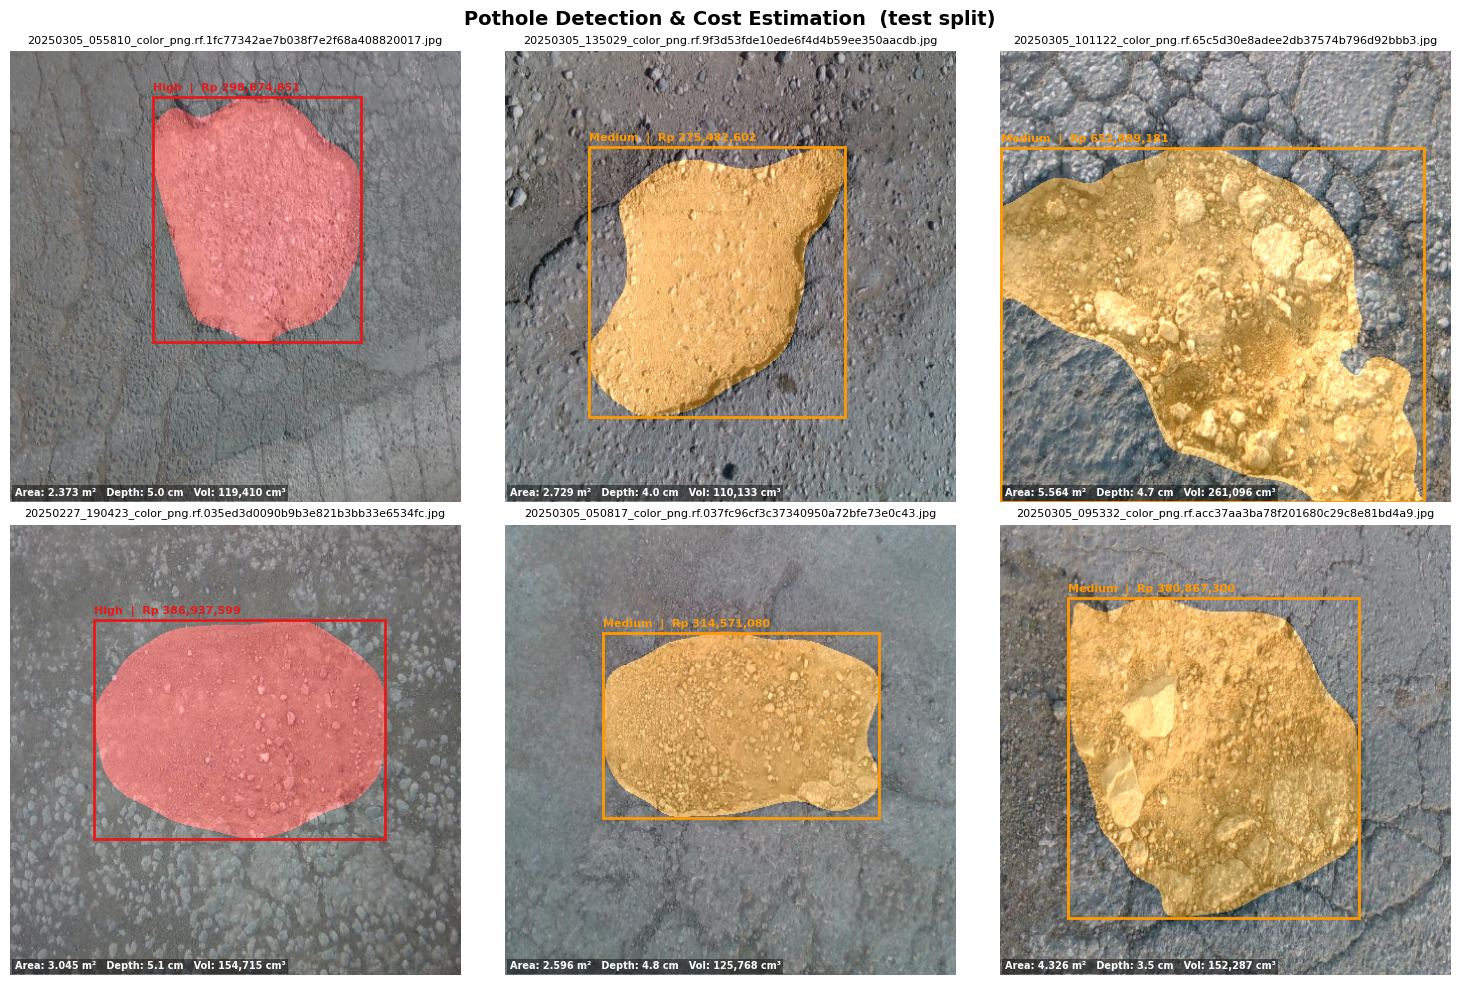


✅ Saved to /kaggle/working/inference_results.png


In [15]:
# ============================================================
# INFERENCE  —  fully self-contained, no local imports needed
# Just run this cell after your training cell.
# ============================================================

import os
import glob
import random
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ── CONFIG ───────────────────────────────────────────────────
CHECKPOINT   = "/kaggle/working/best_model.pth"
DATASET_PATH = "/kaggle/working/pothrgbd_split"
IMG_SIZE     = 448
THRESHOLD    = 0.5
NUM_SAMPLES  = 6
SPLIT        = 'test'
SEED         = 42

SEVERITY_COLOURS = {
    "Low"    : (0.20, 0.80, 0.20),
    "Medium" : (1.00, 0.60, 0.00),
    "High"   : (0.90, 0.10, 0.10),
    "None"   : (0.60, 0.60, 0.60),
}

# IDR cost constants
K_IDR_PER_CM3        = 2_500.0    # Rp per cm³ of asphalt repair
F_IDR_FIXED          = 150_000.0  # fixed mobilisation overhead per pothole
ASSUMED_ROAD_WIDTH_M = 3.5        # Indonesian urban lane width (m)
DEPTH_MIN_CM         = 1.0
DEPTH_MAX_CM         = 8.0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# ── MODEL DEFINITION (inlined from model.py) ─────────────────

class ASPP(nn.Module):
    def __init__(self, in_channels=768, out_channels=256):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
        )
        self.conv2 = self._dilated(in_channels, out_channels, 6)
        self.conv3 = self._dilated(in_channels, out_channels, 12)
        self.conv4 = self._dilated(in_channels, out_channels, 18)
        self.gap = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.GroupNorm(32, out_channels), nn.ReLU(inplace=True),
        )
        self.project = nn.Sequential(
            nn.Conv2d(out_channels * 5, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
            nn.Dropout2d(p=0.1),
        )

    @staticmethod
    def _dilated(in_ch, out_ch, rate):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=rate, dilation=rate, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        _, _, H, W = x.shape
        gap_out = F.interpolate(self.gap(x), size=(H, W),
                                mode='bilinear', align_corners=False)
        return self.project(torch.cat([
            self.conv1(x), self.conv2(x),
            self.conv3(x), self.conv4(x), gap_out,
        ], dim=1))


class DecoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch, output_size=None, scale_factor=None):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
        self.output_size  = output_size
        self.scale_factor = scale_factor

    def forward(self, x):
        x = self.conv(x)
        if self.output_size is not None:
            x = F.interpolate(x, size=self.output_size,
                              mode='bilinear', align_corners=False)
        elif self.scale_factor is not None:
            x = F.interpolate(x, scale_factor=self.scale_factor,
                              mode='bilinear', align_corners=False)
        return x


class DinoSegmentationModel(nn.Module):
    EMBED_DIM = 768

    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone
        for p in self.backbone.parameters():
            p.requires_grad = False
        self.aspp     = ASPP(self.EMBED_DIM, 256)
        self.dec1     = DecoderBlock(256, 256, scale_factor=2)
        self.dec2     = DecoderBlock(256, 128, scale_factor=2)
        self.dec3     = DecoderBlock(128,  64, scale_factor=2)
        self.dec4     = DecoderBlock( 64,  32, output_size=(448, 448))
        self.seg_head = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):
        feats        = self.backbone.forward_features(x)
        tokens       = feats["x_norm_patchtokens"]          # (B, 1024, 768)
        B, N, C      = tokens.shape
        H = W        = int(N ** 0.5)                        # 32
        feat_map     = tokens.permute(0,2,1).reshape(B,C,H,W)
        neck         = self.aspp(feat_map)
        return self.seg_head(self.dec4(self.dec3(self.dec2(self.dec1(neck)))))


# ── LOAD MODEL ───────────────────────────────────────────────

def load_model():
    backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')
    model    = DinoSegmentationModel(backbone).to(device)
    ckpt     = torch.load(CHECKPOINT, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    model.eval()
    print(f"✅ Model loaded  |  epoch {ckpt['epoch']}  "
          f"|  val Dice {ckpt['val_dice']:.4f}  |  val IoU {ckpt['val_iou']:.4f}")
    return model


# ── MIDAS DEPTH (inlined from cost_estimation.py) ────────────

class MiDaSDepthEstimator:
    def __init__(self):
        print("Loading MiDaS DPT_Large...")
        self.model = torch.hub.load(
            "intel-isl/MiDaS", "DPT_Large", trust_repo=True
        ).to(device).eval()
        transforms        = torch.hub.load("intel-isl/MiDaS", "transforms", trust_repo=True)
        self.transform    = transforms.dpt_transform
        print("✅ MiDaS loaded.")

    @torch.no_grad()
    def estimate(self, rgb_np):
        inp        = self.transform(rgb_np).to(device)
        pred       = self.model(inp)
        pred       = F.interpolate(pred.unsqueeze(1),
                                   size=rgb_np.shape[:2],
                                   mode="bicubic",
                                   align_corners=False).squeeze()
        depth      = pred.cpu().numpy().astype(np.float32)
        depth      = depth.max() - depth                   # invert → deeper = higher
        d_min, d_max = depth.min(), depth.max()
        if d_max - d_min > 1e-6:
            depth  = (depth - d_min) / (d_max - d_min)
        return depth


def compute_cost(mask, depth_map):
    """mask: (H,W) binary uint8  |  depth_map: (H,W) float32 [0,1]"""
    m        = mask.astype(bool)
    area_px  = float(m.sum())

    if area_px == 0:
        return dict(area_px=0, area_m2=0, area_cm2=0,
                    depth_cm=0, volume_cm3=0, severity="None", cost_idr=F_IDR_FIXED)

    m_per_px = ASSUMED_ROAD_WIDTH_M / IMG_SIZE
    area_m2  = area_px * (m_per_px ** 2)
    area_cm2 = area_m2 * 10_000.0

    mean_depth = float(depth_map[m].mean())
    depth_cm   = DEPTH_MIN_CM + mean_depth * (DEPTH_MAX_CM - DEPTH_MIN_CM)

    volume_cm3 = area_cm2 * depth_cm

    if depth_cm < 2.5:
        severity = "Low"
    elif depth_cm < 5.0:
        severity = "Medium"
    else:
        severity = "High"

    cost_idr = K_IDR_PER_CM3 * volume_cm3 + F_IDR_FIXED

    return dict(area_px=area_px, area_m2=area_m2, area_cm2=area_cm2,
                depth_cm=depth_cm, volume_cm3=volume_cm3,
                severity=severity, cost_idr=cost_idr)


# ── PREDICT MASK ─────────────────────────────────────────────

@torch.no_grad()
def predict_mask(model, rgb_np):
    img    = cv2.resize(rgb_np, (IMG_SIZE, IMG_SIZE))
    tensor = torch.tensor(img).permute(2,0,1).float() / 255.0
    tensor = tensor.unsqueeze(0).to(device)
    logits = model(tensor)
    prob   = torch.sigmoid(logits).squeeze().cpu().numpy()
    return (prob > THRESHOLD).astype(np.uint8)


# ── MAIN VISUALISATION ────────────────────────────────────────

def visualize_inference():
    random.seed(SEED)

    img_dir = os.path.join(DATASET_PATH, SPLIT, 'images')
    images  = (glob.glob(os.path.join(img_dir, '*.jpg')) +
               glob.glob(os.path.join(img_dir, '*.png')))

    if not images:
        print(f'No images found in {img_dir}')
        return

    print(f'Found {len(images)} images in {SPLIT} split')
    samples = random.sample(images, min(NUM_SAMPLES, len(images)))

    model  = load_model()
    depth_estimator = MiDaSDepthEstimator()

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for i, img_path in enumerate(samples):
        img_bgr = cv2.imread(img_path)
        rgb_np  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        # ---- Predict ----
        pred_mask  = predict_mask(model, rgb_np)
        depth_map  = depth_estimator.estimate(rgb_np)
        depth_resized = cv2.resize(depth_map, (IMG_SIZE, IMG_SIZE),
                                   interpolation=cv2.INTER_LINEAR)
        est = compute_cost(pred_mask, depth_resized)

        # ---- Display image ----
        disp    = cv2.resize(rgb_np, (IMG_SIZE, IMG_SIZE))
        sev_col = SEVERITY_COLOURS.get(est["severity"], SEVERITY_COLOURS["None"])
        col_rgb = (int(sev_col[0]*255), int(sev_col[1]*255), int(sev_col[2]*255))

        # Mask colour overlay
        color_map = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        color_map[pred_mask == 1] = col_rgb
        disp = cv2.addWeighted(disp, 1.0, color_map, 0.45, 0)

        # Bounding boxes from contours
        contours, _ = cv2.findContours(pred_mask, cv2.RETR_EXTERNAL,
                                        cv2.CHAIN_APPROX_SIMPLE)
        ax = axes[i]
        ax.imshow(disp)

        for cnt in contours:
            x, y, bw, bh = cv2.boundingRect(cnt)
            ax.add_patch(patches.Rectangle(
                (x, y), bw, bh,
                linewidth=2, edgecolor=sev_col, facecolor='none'
            ))

        # Severity + cost label
        if contours:
            x, y, _, _ = cv2.boundingRect(contours[0])
            ax.text(x, max(y - 6, 12),
                    f"{est['severity']}  |  Rp {est['cost_idr']:,.0f}",
                    color=sev_col, fontsize=8, fontweight='bold')

        # Stats strip
        ax.text(4, IMG_SIZE - 6,
                f"Area: {est['area_m2']:.3f} m²   "
                f"Depth: {est['depth_cm']:.1f} cm   "
                f"Vol: {est['volume_cm3']:,.0f} cm³",
                color='white', fontsize=7, fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.45, pad=2, linewidth=0))

        ax.set_title(os.path.basename(img_path), fontsize=8)
        ax.axis('off')

        print(f"[{i+1}] {os.path.basename(img_path):<30}  "
              f"severity={est['severity']:<6}  "
              f"Rp {est['cost_idr']:>12,.0f}  "
              f"area={est['area_m2']:.3f}m²  "
              f"depth={est['depth_cm']:.1f}cm")

    plt.suptitle(f'Pothole Detection & Cost Estimation  ({SPLIT} split)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    out_path = '/kaggle/working/inference_results.png'
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\n✅ Saved to {out_path}')


visualize_inference()

------------

Model Evaluation

Device: cuda
Evaluating on 700 images from train split...


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


Model loaded.


Evaluating: 100%|██████████| 700/700 [01:18<00:00,  8.95it/s]



SEGMENTATION EVALUATION
Metric            Mean       Std       Min       Max
------------------------------------------------------------
Dice            0.9360    0.0730    0.0000    0.9936
IoU             0.8855    0.0875    0.0000    0.9873
Precision       0.9329    0.0846    0.0000    0.9994
Recall          0.9475    0.0507    0.5371    1.0000
F1              0.9360    0.0730    0.0000    0.9936


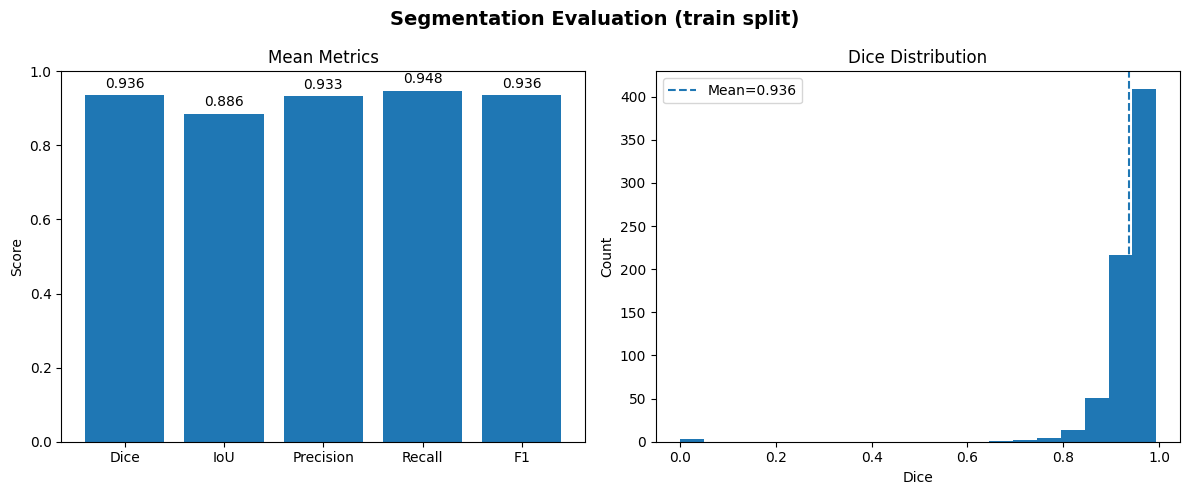

Saved to /kaggle/working/evaluation_results_segmentation.png


In [16]:
# ============================================================
# CORRECTED MODEL EVALUATION FOR PothRGBD SEGMENTATION
# Key fixes:
# 1) GT masks are parsed from YOLO segmentation polygons, not bbox
# 2) Evaluation preprocessing matches common DINO-style normalization
# 3) Uses dataset split path correctly
# 4) Keeps segmentation evaluation clean
# ============================================================

import os
import glob
import random
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm

# ── CONFIG ───────────────────────────────────────────────────
CHECKPOINT   = "/kaggle/working/best_model.pth"
DATASET_PATH = "/kaggle/working/pothrgbd_split"
IMG_SIZE     = 448
THRESHOLD    = 0.5
SPLIT        = "train"   # use "valid" during development, "test" for final report
SEED         = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# ── MODEL ────────────────────────────────────────────────────
class ASPP(nn.Module):
    def __init__(self, in_channels=768, out_channels=256):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
        )
        self.conv2 = self._dilated(in_channels, out_channels, 6)
        self.conv3 = self._dilated(in_channels, out_channels, 12)
        self.conv4 = self._dilated(in_channels, out_channels, 18)
        self.gap = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.GroupNorm(32, out_channels), nn.ReLU(inplace=True),
        )
        self.project = nn.Sequential(
            nn.Conv2d(out_channels * 5, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
            nn.Dropout2d(p=0.1),
        )

    @staticmethod
    def _dilated(in_ch, out_ch, rate):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=rate, dilation=rate, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        _, _, H, W = x.shape
        gap_out = F.interpolate(self.gap(x), size=(H, W), mode="bilinear", align_corners=False)
        return self.project(torch.cat([
            self.conv1(x), self.conv2(x), self.conv3(x), self.conv4(x), gap_out
        ], dim=1))


class DecoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch, output_size=None, scale_factor=None):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
        self.output_size = output_size
        self.scale_factor = scale_factor

    def forward(self, x):
        x = self.conv(x)
        if self.output_size is not None:
            x = F.interpolate(x, size=self.output_size, mode="bilinear", align_corners=False)
        elif self.scale_factor is not None:
            x = F.interpolate(x, scale_factor=self.scale_factor, mode="bilinear", align_corners=False)
        return x


class DinoSegmentationModel(nn.Module):
    EMBED_DIM = 768

    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone
        for p in self.backbone.parameters():
            p.requires_grad = False

        self.aspp = ASPP(self.EMBED_DIM, 256)
        self.dec1 = DecoderBlock(256, 256, scale_factor=2)
        self.dec2 = DecoderBlock(256, 128, scale_factor=2)
        self.dec3 = DecoderBlock(128, 64, scale_factor=2)
        self.dec4 = DecoderBlock(64, 32, output_size=(IMG_SIZE, IMG_SIZE))
        self.seg_head = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):
        feats = self.backbone.forward_features(x)
        tokens = feats["x_norm_patchtokens"]
        B, N, C = tokens.shape
        H = W = int(N ** 0.5)
        feat_map = tokens.permute(0, 2, 1).reshape(B, C, H, W)
        neck = self.aspp(feat_map)
        out = self.dec1(neck)
        out = self.dec2(out)
        out = self.dec3(out)
        out = self.dec4(out)
        return self.seg_head(out)


def load_model():
    backbone = torch.hub.load("facebookresearch/dinov2", "dinov2_vitb14")
    model = DinoSegmentationModel(backbone).to(device)

    ckpt = torch.load(CHECKPOINT, map_location=device)

    if "model_state" in ckpt:
        model.load_state_dict(ckpt["model_state"])
    elif "model_state_dict" in ckpt:
        model.load_state_dict(ckpt["model_state_dict"])
    else:
        model.load_state_dict(ckpt)

    model.eval()
    print("Model loaded.")
    return model


# ── PREPROCESSING ────────────────────────────────────────────
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def preprocess_rgb(rgb_np):
    img = cv2.resize(rgb_np, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR)
    img = img.astype(np.float32) / 255.0
    img = (img - IMAGENET_MEAN) / IMAGENET_STD
    img = np.transpose(img, (2, 0, 1))
    tensor = torch.tensor(img, dtype=torch.float32).unsqueeze(0).to(device)
    return tensor


@torch.no_grad()
def predict_mask(model, rgb_np):
    tensor = preprocess_rgb(rgb_np)
    logits = model(tensor)
    probs = torch.sigmoid(logits).squeeze().cpu().numpy()
    pred = (probs > THRESHOLD).astype(np.uint8)
    return pred


# ── CORRECT GT MASK LOADER: YOLO SEGMENTATION POLYGONS ──────
def load_gt_mask(label_path):
    """
    YOLO segmentation format:
    class_id x1 y1 x2 y2 x3 y3 ... xN yN
    coordinates are normalized in [0,1]
    """
    mask = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)

    if not os.path.exists(label_path):
        return mask

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        if len(parts) < 7:
            continue  # need at least class + 3 points

        coords = list(map(float, parts[1:]))

        if len(coords) % 2 != 0:
            continue

        pts = []
        for i in range(0, len(coords), 2):
            x = int(coords[i] * IMG_SIZE)
            y = int(coords[i + 1] * IMG_SIZE)
            x = max(0, min(IMG_SIZE - 1, x))
            y = max(0, min(IMG_SIZE - 1, y))
            pts.append([x, y])

        if len(pts) >= 3:
            pts = np.array(pts, dtype=np.int32)
            cv2.fillPoly(mask, [pts], 1)

    return mask


# ── SEGMENTATION METRICS ─────────────────────────────────────
def seg_metrics(pred, gt):
    pred = pred.astype(np.uint8)
    gt = gt.astype(np.uint8)

    TP = np.logical_and(pred == 1, gt == 1).sum()
    FP = np.logical_and(pred == 1, gt == 0).sum()
    FN = np.logical_and(pred == 0, gt == 1).sum()

    precision = (TP + 1e-8) / (TP + FP + 1e-8)
    recall    = (TP + 1e-8) / (TP + FN + 1e-8)
    dice      = (2 * TP + 1e-8) / (2 * TP + FP + FN + 1e-8)
    iou       = (TP + 1e-8) / (TP + FP + FN + 1e-8)
    f1        = dice

    return {
        "dice": float(dice),
        "iou": float(iou),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
    }


def print_summary(results):
    dices      = np.array([r["dice"] for r in results])
    ious       = np.array([r["iou"] for r in results])
    precisions = np.array([r["precision"] for r in results])
    recalls    = np.array([r["recall"] for r in results])
    f1s        = np.array([r["f1"] for r in results])

    print("\n" + "=" * 60)
    print("SEGMENTATION EVALUATION")
    print("=" * 60)
    print(f"{'Metric':<12}{'Mean':>10}{'Std':>10}{'Min':>10}{'Max':>10}")
    print("-" * 60)

    for name, arr in [
        ("Dice", dices),
        ("IoU", ious),
        ("Precision", precisions),
        ("Recall", recalls),
        ("F1", f1s),
    ]:
        print(f"{name:<12}{arr.mean():>10.4f}{arr.std():>10.4f}{arr.min():>10.4f}{arr.max():>10.4f}")


def plot_evaluation(results, out_path="/kaggle/working/evaluation_results_segmentation.png"):
    dices      = [r["dice"] for r in results]
    ious       = [r["iou"] for r in results]
    precisions = [r["precision"] for r in results]
    recalls    = [r["recall"] for r in results]
    f1s        = [r["f1"] for r in results]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"Segmentation Evaluation ({SPLIT} split)", fontsize=14, fontweight="bold")

    metric_names = ["Dice", "IoU", "Precision", "Recall", "F1"]
    metric_vals  = [np.mean(dices), np.mean(ious), np.mean(precisions), np.mean(recalls), np.mean(f1s)]

    ax = axes[0]
    bars = ax.bar(metric_names, metric_vals)
    ax.set_ylim(0, 1.0)
    ax.set_title("Mean Metrics")
    ax.set_ylabel("Score")
    for bar, val in zip(bars, metric_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02, f"{val:.3f}", ha="center")

    ax = axes[1]
    ax.hist(dices, bins=20)
    ax.axvline(np.mean(dices), linestyle="--", label=f"Mean={np.mean(dices):.3f}")
    ax.set_title("Dice Distribution")
    ax.set_xlabel("Dice")
    ax.set_ylabel("Count")
    ax.legend()

    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved to {out_path}")


# ── OPTIONAL DEBUG VISUALIZER ────────────────────────────────
def debug_visualize_samples(model, num_samples=5):
    img_dir = os.path.join(DATASET_PATH, SPLIT, "images")
    lbl_dir = os.path.join(DATASET_PATH, SPLIT, "labels")

    images = sorted(glob.glob(os.path.join(img_dir, "*.jpg")) + glob.glob(os.path.join(img_dir, "*.png")))
    chosen = random.sample(images, min(num_samples, len(images)))

    for img_path in chosen:
        stem = os.path.splitext(os.path.basename(img_path))[0]
        label_path = os.path.join(lbl_dir, stem + ".txt")

        img_bgr = cv2.imread(img_path)
        rgb_np = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        pred_mask = predict_mask(model, rgb_np)
        gt_mask = load_gt_mask(label_path)
        m = seg_metrics(pred_mask, gt_mask)

        img_resized = cv2.resize(rgb_np, (IMG_SIZE, IMG_SIZE))

        fig, axes = plt.subplots(1, 3, figsize=(14, 4))
        axes[0].imshow(img_resized)
        axes[0].set_title("Image")
        axes[1].imshow(gt_mask, cmap="gray")
        axes[1].set_title("GT Mask")
        axes[2].imshow(img_resized)
        axes[2].imshow(pred_mask, alpha=0.45, cmap="Reds")
        axes[2].set_title(f"Pred Mask\nDice={m['dice']:.3f}, IoU={m['iou']:.3f}")

        for ax in axes:
            ax.axis("off")
        plt.show()


# ── MAIN ─────────────────────────────────────────────────────
def run_evaluation():
    random.seed(SEED)

    img_dir = os.path.join(DATASET_PATH, SPLIT, "images")
    lbl_dir = os.path.join(DATASET_PATH, SPLIT, "labels")

    images = sorted(glob.glob(os.path.join(img_dir, "*.jpg")) + glob.glob(os.path.join(img_dir, "*.png")))

    if not images:
        print(f"No images found in {img_dir}")
        return

    print(f"Evaluating on {len(images)} images from {SPLIT} split...")

    model = load_model()
    results = []

    for img_path in tqdm(images, desc="Evaluating"):
        stem = os.path.splitext(os.path.basename(img_path))[0]
        label_path = os.path.join(lbl_dir, stem + ".txt")

        img_bgr = cv2.imread(img_path)
        rgb_np = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        pred_mask = predict_mask(model, rgb_np)
        gt_mask = load_gt_mask(label_path)

        results.append(seg_metrics(pred_mask, gt_mask))

    print_summary(results)
    plot_evaluation(results)

    return model, results


model, results = run_evaluation()
# debug_visualize_samples(model, num_samples=5)